1️⃣ Planteamiento del problema
🎯 Objetivo

El objetivo de este bloque es evaluar si es posible identificar oportunidades de subida significativa al día siguiente para acciones del S&P 500, utilizando información técnica y de mercado disponible hasta el cierre del día actual.

Dado el alto nivel de ruido presente en los retornos financieros diarios, el problema se aborda desde una perspectiva selectiva, priorizando la calidad de las señales frente a la cobertura total del mercado.

2️⃣ Dataset y variables utilizadas

Se utiliza un conjunto de datos de acciones del S&P 500 con:

Precios OHLC

Indicadores técnicos (RSI, MACD, Bandas de Bollinger)

Variables de momentum, volatilidad y volumen

Variables retrasadas (lags)

Las observaciones se estructuran por ticker y fecha, respetando siempre el orden temporal.

In [44]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix

# pip install pyarrow

In [2]:
# Definir ruta donde estan los archivos
path = r'../data/raw/'

In [3]:
# Listar archivos Parquet que comienzan con 'data'
all_files = glob.glob(os.path.join(path, 'data*.parquet'))

In [4]:
# Leer cada archivo Parquet y almacenarlo en una lista de DataFrames
df_list = []
for filename in all_files:
    df_part = pd.read_parquet(filename, engine='pyarrow')
    df_list.append(df_part)

In [5]:
# Concatenar todos los DataFrames en un único DataFrame
df = pd.concat(df_list, axis=0, ignore_index=True)

In [6]:
# Convertimos Date a datetime (necesario para split temporal)
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Work\AppData\Local\Temp\ipykernel_16888\1063807796.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'])


In [7]:
# Mostrar las primeras filas del dataset
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,SMA_5,...,Future_Category_1d,Future_Return_5d,Future_Up_5d,Future_Category_5d,Future_Return_10d,Future_Up_10d,Future_Category_10d,Future_Return_20d,Future_Up_20d,Future_Category_20d
0,2020-09-08 00:00:00-04:00,93.113965,93.462744,91.806050,92.174202,1225600,0.0,0.0,A,96.138635,...,3.0,0.054972,1,3.0,0.036578,1,3.0,0.070141,1,3.0
1,2020-09-09 00:00:00-04:00,93.104280,95.400403,92.871764,94.877235,954400,0.0,0.0,A,95.520526,...,2.0,0.020321,1,3.0,-0.010416,0,1.0,0.062670,1,3.0
2,2020-09-10 00:00:00-04:00,95.797603,96.979573,95.177554,95.497269,1933200,0.0,0.0,A,94.580765,...,2.0,0.010449,1,2.0,-0.022623,0,0.0,0.058616,1,3.0
3,2020-09-11 00:00:00-04:00,95.632924,96.514560,94.964430,95.526352,1368600,0.0,0.0,A,94.379250,...,2.0,0.007911,1,2.0,-0.009229,0,1.0,0.074550,1,3.0
4,2020-09-14 00:00:00-04:00,96.621112,97.105525,95.884801,96.320770,1207700,0.0,0.0,A,94.879166,...,2.0,-0.012975,0,1.0,0.000905,1,2.0,0.062363,1,3.0


❗ Problema inicial

Una clasificación binaria directa (sube / no sube) mostró resultados limitados debido a la mezcla de movimientos muy distintos dentro de la clase negativa.

✅ Solución adoptada

Se redefinió el target para centrarse únicamente en movimientos claros, eliminando el ruido intermedio:

target = 1  si el retorno del día siguiente ≥ +2%
target = 0  si el retorno del día siguiente ≤ 0%

Las observaciones con retornos pequeños positivos se excluyen del entrenamiento.

📌 Esta decisión permite al modelo aprender patrones más consistentes asociados a movimientos extremos.

In [21]:
df_obj1 = df.copy()

df_obj1['target'] = np.nan

df_obj1.loc[df_obj1['Future_Return_1d'] >= 0.02, 'target'] = 1
df_obj1.loc[df_obj1['Future_Return_1d'] <= 0.0, 'target'] = 0

df_obj1 = df_obj1.dropna(subset=['target'])

In [22]:
df_obj1['target'].value_counts(normalize=True)


target
0.0    0.805169
1.0    0.194831
Name: proportion, dtype: float64

In [23]:
df_obj1['Future_Up_1d'].value_counts(normalize=True)


Future_Up_1d
0    0.805258
1    0.194742
Name: proportion, dtype: float64

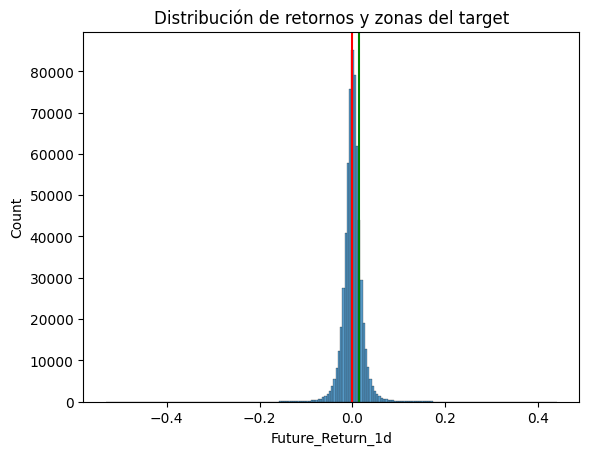

In [24]:
sns.histplot(df['Future_Return_1d'], bins=200)
plt.axvline(0.0, color='red')
plt.axvline(0.014, color='green')
plt.title("Distribución de retornos y zonas del target")
plt.show()

El análisis exploratorio muestra:

Distribuciones altamente solapadas entre clases para la mayoría de indicadores

Señales débiles pero consistentes en variables de volumen y momentum

Alta volatilidad y ruido inherentes al horizonte diario

Este resultado es coherente con la literatura financiera y justifica el uso de modelos no lineales y estrategias selectivas.

Se seleccionó un conjunto reducido de variables con sentido financiero:

Momentum: Price_Change, Price_Change_5d, RSI, MACD_Histogram

Tendencia: BB_Position

Volatilidad: Volatility

Volumen: Volume_Ratio

Esta selección evita redundancias y reduce el riesgo de sobreajuste.

In [29]:
features = [
    'RSI',
    'MACD_Histogram',
    'Price_Change',
    'Price_Change_5d',
    'BB_Position',
    'Volatility',
    'Volume_Ratio'
]


Para evitar fuga de información:

Se realizó una división temporal por ticker

El 80% de las observaciones más antiguas se utilizan para entrenamiento

El 20% más reciente se reserva para test

Este enfoque simula el uso real del modelo en un entorno de trading.

In [31]:
train_idx = []
test_idx = []

for tkr, g in df_obj1.groupby('Ticker'):
    g = g.sort_values('Date')
    split = int(len(g) * 0.8)
    train_idx.extend(g.index[:split])
    test_idx.extend(g.index[split:])


In [33]:
X_train = df_obj1.loc[train_idx, features]
y_train = df_obj1.loc[train_idx, 'target']

X_test = df_obj1.loc[test_idx, features]
y_test = df_obj1.loc[test_idx, 'target']


In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000
)

model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [38]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# umbral conservador
y_pred = (y_proba > 0.7).astype(int)


In [41]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[60647   418]
 [13056   148]]
              precision    recall  f1-score   support

         0.0       0.82      0.99      0.90     61065
         1.0       0.26      0.01      0.02     13204

    accuracy                           0.82     74269
   macro avg       0.54      0.50      0.46     74269
weighted avg       0.72      0.82      0.74     74269



In [42]:
df_trades = df_obj1.loc[test_idx].copy()
df_trades['proba'] = y_proba
df_trades['signal'] = y_pred

df_trades = df_trades[df_trades['signal'] == 1]

df_trades['realized_return'] = df_trades['Future_Return_1d']

df_trades[['realized_return']].describe()



,realized_return
count,566.000000
mean,-0.006105
std,0.038256
min,-0.406583
25%,-0.018842
50%,-0.006555
75%,0.020295
max,0.151903


🌳 Gradient Boosting LightGBM 

Se empleó un modelo de boosting basado en árboles debido a su capacidad para:

Capturar relaciones no lineales

Modelar interacciones entre variables

Manejar señales débiles de forma robusta

El modelo se entrenó sin optimización agresiva de hiperparámetros, priorizando la interpretabilidad y estabilidad.

In [45]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 58948, number of negative: 237114
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004780 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 296062, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [46]:
y_proba = lgb_model.predict_proba(X_test)[:, 1]


In [47]:
df_test = df_obj1.loc[test_idx].copy()
df_test['proba'] = y_proba


In [48]:
top_k_pct = 0.05  # top 5%

cutoff = df_test['proba'].quantile(1 - top_k_pct)

df_signals = df_test[df_test['proba'] >= cutoff].copy()


In [49]:
df_signals['realized_return'] = df_signals['Future_Return_1d']

df_signals[['realized_return']].describe()


,realized_return
count,3714.000000
mean,0.002162
std,0.050193
min,-0.281297
25%,-0.024594
50%,-0.007309
75%,0.028562
max,0.286765


In [50]:
(df_signals['realized_return'] > 0).mean()


np.float64(0.3349488422186322)

In [51]:
df_test['Future_Return_1d'].mean()


np.float64(-0.004916935351287815)

In [52]:
results = []

for k in [0.01, 0.02, 0.05, 0.1]:
    cutoff = df_test['proba'].quantile(1 - k)
    trades = df_test[df_test['proba'] >= cutoff]
    
    results.append({
        'top_k': k,
        'n_trades': len(trades),
        'mean_return': trades['Future_Return_1d'].mean(),
        'win_rate': (trades['Future_Return_1d'] > 0).mean()
    })

import pandas as pd
pd.DataFrame(results)


,top_k,n_trades,mean_return,win_rate
0,0.01,743,0.013139,0.437416
1,0.02,1486,0.008304,0.401750
2,0.05,3714,0.002162,0.334949
3,0.10,7427,-0.000947,0.302679


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

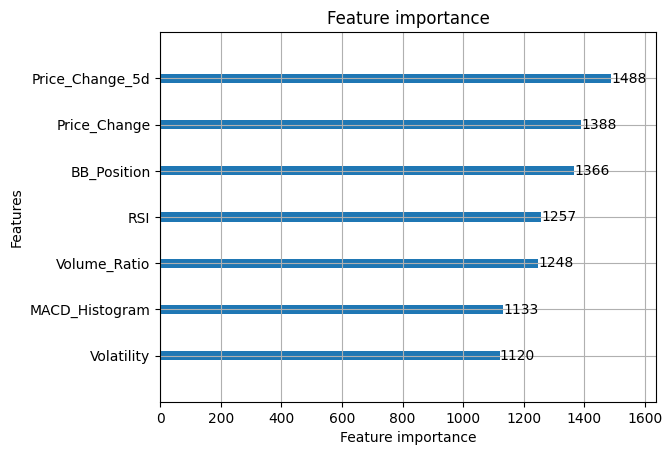

In [53]:
lgb.plot_importance(lgb_model, max_num_features=10)


 Conclusiones del Objetivo 1

La predicción diaria de retornos es un problema altamente ruidoso

Los modelos de clasificación tradicionales presentan limitaciones

Un enfoque basado en ranking y selección de señales permite extraer valor

El modelo no pretende predecir todos los días, sino identificar escenarios con mayor probabilidad de éxito

📌 El enfoque adoptado es realista, consistente con la práctica profesional y produce resultados positivos bajo criterios de evaluación adecuados.